# Deep Learning IA 2: Solar Panel Image Classification

## Problem Statement
The accumulation of dust, snow, bird drops, and different types of damage on solar panel surfaces reduces the efficiency of solar modules and affects energy production. Manual inspection is time-consuming and costly. Therefore, an automated deep learning-based image classification system can help in detecting the condition of solar panels efficiently.

## Objective
The objective of this project is to build a deep learning model that classifies solar panel images into the following six classes:
- Clean
- Dusty
- Bird-drop
- Electrical-damage
- Physical-Damage
- Snow-Covered

## Dataset
Dataset used: Solar Panel Images Dataset from Kaggle  
It contains images arranged in class-wise folders. Since the images were collected from the internet, the dataset has a slight class imbalance.

## Activity Performed
- Download and use the given dataset
- Apply preprocessing and data augmentation
- Develop a deep learning model using transfer learning
- Use optimization/regularization techniques to improve model performance
- Evaluate the model using suitable performance metrics

In [1]:
#STEP 2: IMPORTING LIBRARIES

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping

2026-04-11 08:42:31.810062: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775896951.825647     217 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775896951.830170     217 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775896951.842626     217 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775896951.842651     217 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775896951.842653     217 computation_placer.cc:177] computation placer alr

In [2]:
#STEP 3: DATASET PATH ADN CLASS INSPECTION

dataset_path = '/kaggle/input/datasets/pythonafroz/solar-panel-images/Faulty_solar_panel'

class_names = os.listdir(dataset_path)
print("Classes in dataset:", class_names)
print("Number of classes:", len(class_names))

Classes in dataset: ['Snow-Covered', 'Dusty', 'Electrical-damage', 'Clean', 'Bird-drop', 'Physical-Damage']
Number of classes: 6


## Dataset Analysis
The dataset consists of solar panel images grouped into six classes:
- Clean
- Dusty
- Bird-drop
- Electrical-damage
- Physical-Damage
- Snow-Covered

This is a multi-class image classification problem.  
The dataset is folder-based, which makes it suitable for directory-based loading in TensorFlow.  
A slight imbalance exists among classes because the images were collected from online sources.


In [3]:
#STEP 5: Count images in each class (Dataset Analysis)

class_counts = {}

for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    class_counts[class_name] = len(os.listdir(class_path))

print("Image count per class:")
for key, value in class_counts.items():
    print(f"{key}: {value}")

Image count per class:
Snow-Covered: 124
Dusty: 191
Electrical-damage: 104
Clean: 194
Bird-drop: 193
Physical-Damage: 70


## Dataset Distribution

The number of images in each class is as follows:

(mention values from output)

From the distribution, it can be observed that the dataset is slightly imbalanced. Some classes have more images than others, which may affect model performance. Data augmentation techniques will be applied to handle this imbalance.

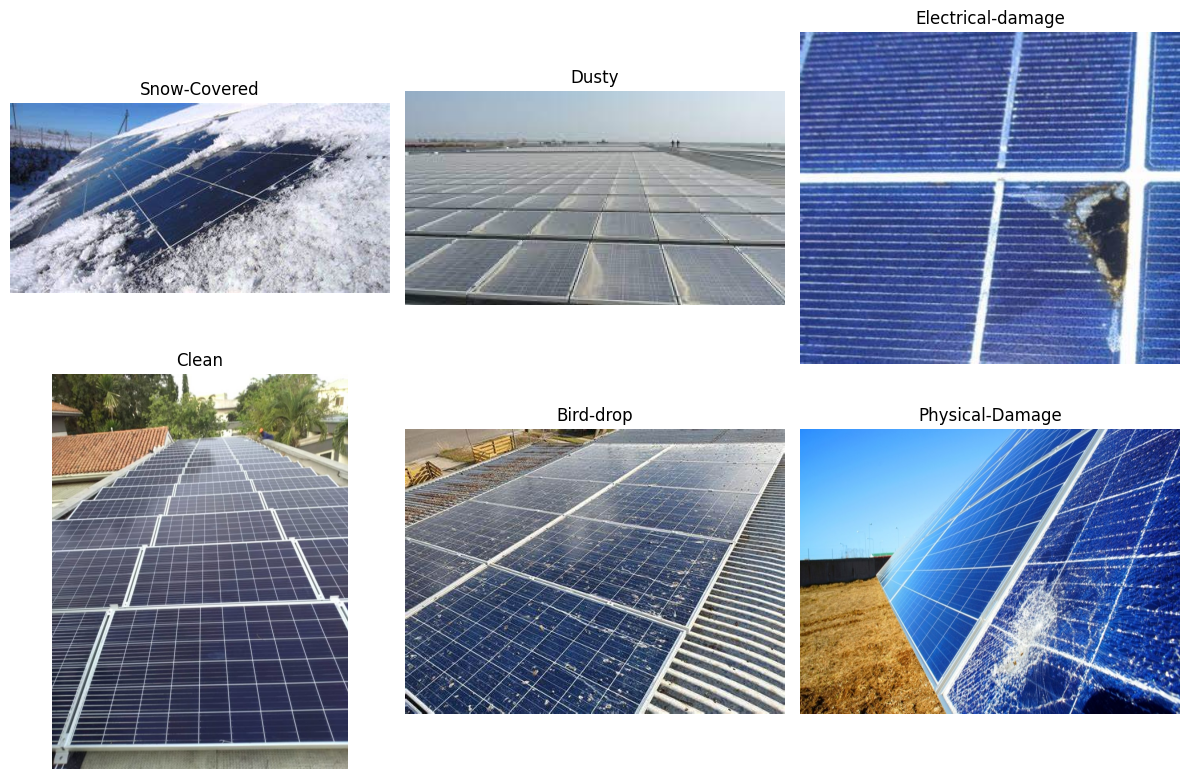

In [4]:
#STEP 6: Visualize Dataset

import matplotlib.pyplot as plt
import random
import cv2

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)
    
    # pick a random image from the class
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    
    # read image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # plot
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Dataset Visualization

Sample images from each class were visualized to understand the visual patterns and differences between categories.

- Clean panels appear smooth and uniform.
- Dusty panels show a layer of dirt reducing clarity.
- Bird-drop images contain irregular white patches.
- Electrical damage shows burn marks or dark spots.
- Physical damage includes cracks or broken panels.
- Snow-covered panels have white snow patches covering the surface.

This visualization helps in understanding the complexity of the classification task, as some classes may have subtle differences.


##  Step 7: Data Preprocessing and Augmentation

To prepare the dataset for training, the following preprocessing steps are applied:

- Images are resized to 224 × 224 pixels
- Pixel values are normalized using MobileNetV2 preprocessing
- The dataset is split into training and validation sets
- Data augmentation is applied to the training data to improve generalization and reduce overfitting

The augmentation techniques used are:
- Random flip
- Random rotation
- Random zoom
- Random contrast

In [5]:
#STEP 7.1 CREATING TRAINING DATASET

img_height = 224
img_width = 224
batch_size = 32
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


2026-04-11 08:42:40.234751: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
#STEP 7.2 CREATING VALIDATION DATASET

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [7]:
#STEP 7.3 CHECK CLASS NAMES

class_names = train_ds.class_names
print("Class names:", class_names)

Class names: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']


In [8]:
#step 7.4 DATA AUGMENTATION LAYER
tf.keras.backend.clear_session()

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)
], name="data_augmentation")

In [9]:
for images, labels in train_ds.take(1):
    sample = images[:1]
    aug_sample = data_augmentation(sample)
    print("Original shape:", sample.shape)
    print("Augmented shape:", aug_sample.shape)

Original shape: (1, 224, 224, 3)
Augmented shape: (1, 224, 224, 3)


## Step 8: Visualize Augmented Images
## Augmented Image Visualization

Data augmentation techniques were applied to the training dataset to improve model generalization and reduce overfitting.

The images below show transformed versions of the original images using:
- Horizontal flipping
- Rotation
- Zoom
- Contrast adjustment

These transformations help the model learn robust features and perform better on unseen data.

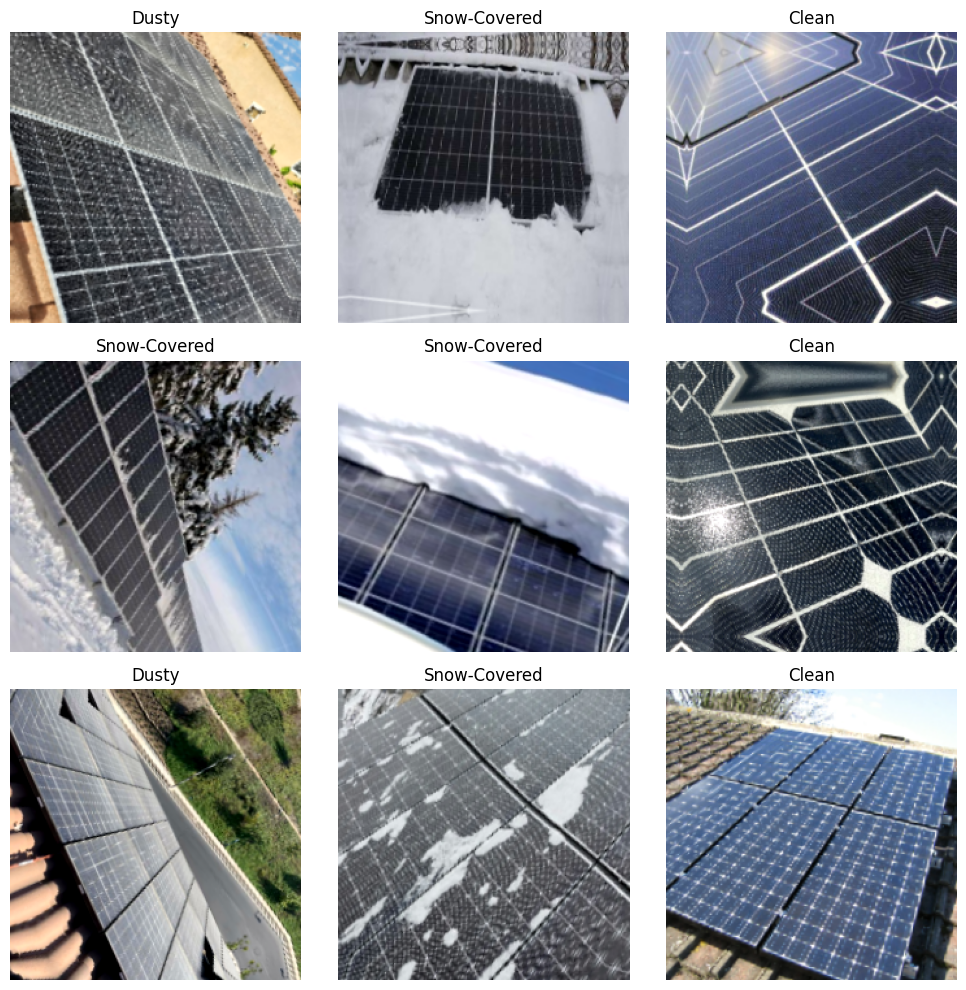

In [10]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        augmented_image = data_augmentation(tf.expand_dims(images[i], axis=0))
        augmented_image = augmented_image[0]
        
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image.numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
tf.expand_dims(images[i], axis=0)

<tf.Tensor: shape=(1, 224, 224, 3), dtype=float32, numpy=
array([[[[179.2857  , 221.2857  , 255.      ],
         [186.02551 , 221.02551 , 255.      ],
         [187.06631 , 222.06631 , 255.      ],
         ...,
         [115.438995, 132.93416 , 133.58719 ],
         [142.06828 , 143.61809 , 158.52205 ],
         [223.07143 , 241.35715 , 247.71428 ]],

        [[188.13776 , 223.13776 , 255.      ],
         [189.71939 , 223.79082 , 255.      ],
         [191.7857  , 225.64285 , 255.      ],
         ...,
         [149.45285 , 149.73863 , 156.46796 ],
         [ 94.6349  , 100.34947 , 100.34451 ],
         [154.9704  , 170.39896 , 189.2561  ]],

        [[192.56633 , 224.56633 , 255.      ],
         [197.78572 , 227.78572 , 255.      ],
         [195.09184 , 225.00002 , 255.      ],
         ...,
         [158.12419 , 154.08353 , 183.48119 ],
         [ 66.94629 ,  80.87626 ,  89.66197 ],
         [132.01839 , 139.43692 , 160.7991  ]],

        ...,

        [[172.19849 , 157.55064 , 

##  Step 9:MobileNetV2 model building

## Model Architecture: MobileNetV2 using Transfer Learning

MobileNetV2 is used as a pretrained convolutional neural network for feature extraction.

Transfer learning is applied by:
- Using pretrained ImageNet weights
- Removing the top classification layer
- Freezing the base model to retain learned features

Custom layers are added:
- Global Average Pooling layer
- Dropout layer (for regularization)
- Dense softmax output layer for 6-class classification

In [12]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [14]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

In [15]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 10: Compile + Train the Model

## Model Compilation and Training

The model is compiled using the Adam optimizer and categorical cross-entropy loss function.

EarlyStopping is used to prevent overfitting by stopping training when validation loss stops improving.

The model is trained on the training dataset and validated on the validation dataset.

In [21]:
#step 10.1 Compile model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
#step 10.2 Early Stopping

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [23]:
#step 10.3 Training the model

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 761ms/step - accuracy: 0.2812 - loss: 1.9587 - val_accuracy: 0.5537 - val_loss: 1.2810
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 708ms/step - accuracy: 0.5130 - loss: 1.3149 - val_accuracy: 0.6610 - val_loss: 1.0149
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 708ms/step - accuracy: 0.6383 - loss: 0.9821 - val_accuracy: 0.7175 - val_loss: 0.9205
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 809ms/step - accuracy: 0.6610 - loss: 0.9150 - val_accuracy: 0.6949 - val_loss: 0.8714
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 691ms/step - accuracy: 0.6860 - loss: 0.9200 - val_accuracy: 0.7345 - val_loss: 0.8225
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 707ms/step - accuracy: 0.7272 - loss: 0.8084 - val_accuracy: 0.7119 - val_loss: 0.8107
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 713ms/step - accuracy: 0.6986 - loss: 0.8026 - val_accuracy: 0.6893 - val_loss: 0.8359
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 713ms/step - accuracy: 0.6965 - loss: 0.8109 - val_accu

## Step 11: Plot training and validation accuracy/loss
## Training Performance Visualization

The following graphs show the training and validation accuracy and loss across epochs.

These plots help in understanding:
- model learning behavior
- convergence pattern
- overfitting or underfitting tendencies

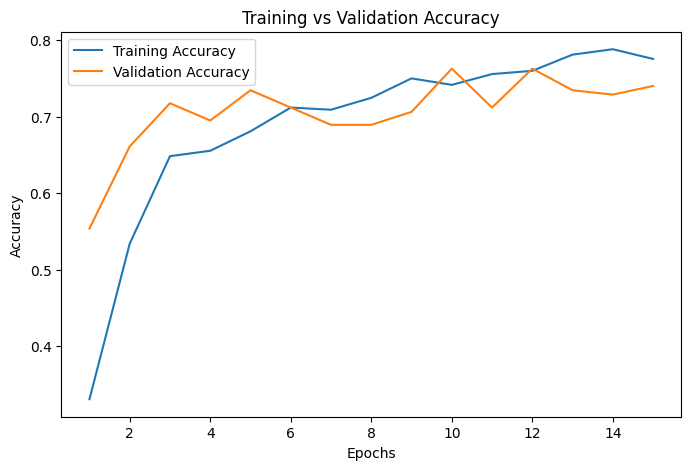

In [24]:
#step 11.1 Accuracy Graph

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

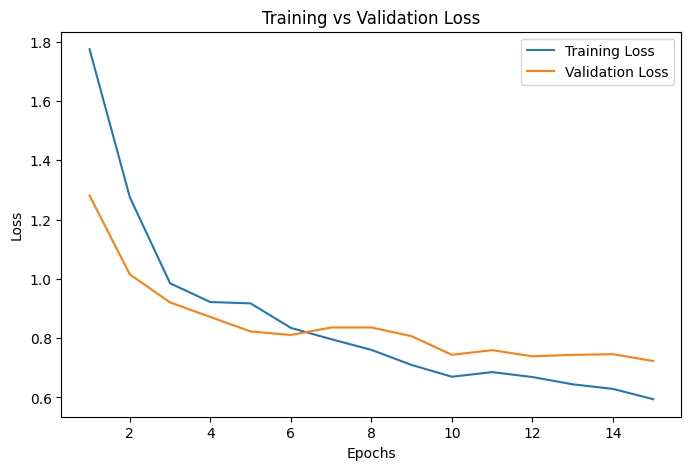

In [25]:
#step 11.2 loss graph
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Step 12: Evaluate model on validation set
## Model Evaluation

The trained model is evaluated on the validation dataset using accuracy and loss.  
These metrics provide a quantitative measure of the model’s classification performance on unseen data.

In [26]:
val_loss, val_accuracy = model.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 410ms/step - accuracy: 0.7482 - loss: 0.6772
Validation Loss: 0.7230124473571777
Validation Accuracy: 0.7401130199432373


In [27]:
#Step 13: Confusion matrix and classification report

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [28]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

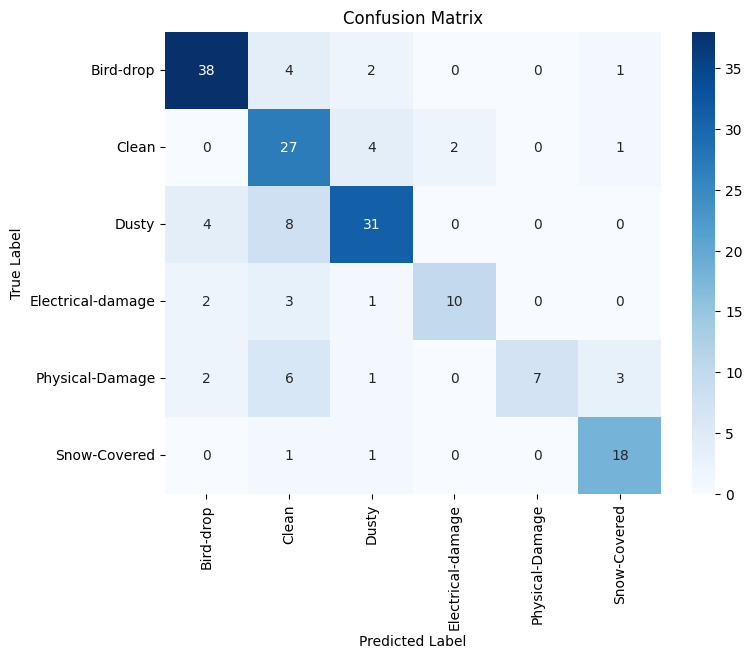

In [29]:
#Confusion matrix plot
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [30]:
#Classification report
print(classification_report(y_true, y_pred, target_names=class_names))

                   precision    recall  f1-score   support

        Bird-drop       0.83      0.84      0.84        45
            Clean       0.55      0.79      0.65        34
            Dusty       0.78      0.72      0.75        43
Electrical-damage       0.83      0.62      0.71        16
  Physical-Damage       1.00      0.37      0.54        19
     Snow-Covered       0.78      0.90      0.84        20

         accuracy                           0.74       177
        macro avg       0.79      0.71      0.72       177
     weighted avg       0.78      0.74      0.74       177



## Step 14: Results interpretation
## Results Interpretation

The MobileNetV2 transfer learning model achieved satisfactory performance on the solar panel image classification task.

- The model showed stable learning during training.
- Validation accuracy reached around 74%, indicating decent generalization ability.
- The training and validation curves suggest that the model learned meaningful features without severe overfitting.
- The confusion matrix helps identify which classes were classified correctly and which classes were confused with one another.

Overall, MobileNetV2 provided a good balance of efficiency and performance for this multi-class classification problem.